# Initialize Data Folders

Samples 17 random images from each of the 3 sketch folders in `FS2K/FS2K/sketch` (sketch1, sketch2, sketch3) and replaces the contents of `animations/eric_andre/images_to_animate` with the 51 sampled images.

In [1]:
import os
import shutil
import random
from pathlib import Path

In [2]:
# Paths — adjust REPO_ROOT if running from a different working directory
REPO_ROOT = Path(os.getcwd()).parent
SKETCH_ROOT = REPO_ROOT / "FS2K" / "FS2K" / "sketch"
OUTPUT_DIR  = REPO_ROOT / "animations" / "eric_andre" / "images_to_animate"

SAMPLES_PER_FOLDER = 17
SEED = 42  # set to None for a different random draw each run

print(f"Sketch root : {SKETCH_ROOT}")
print(f"Output dir  : {OUTPUT_DIR}")

Sketch root : /mnt/c/Users/zdzhn/ganimation/FS2K/FS2K/sketch
Output dir  : /mnt/c/Users/zdzhn/ganimation/animations/eric_andre/images_to_animate


In [3]:
# Discover sketch sub-folders
sketch_folders = sorted([p for p in SKETCH_ROOT.iterdir() if p.is_dir()])
print(f"Found {len(sketch_folders)} sketch folders: {[f.name for f in sketch_folders]}")

Found 3 sketch folders: ['sketch1', 'sketch2', 'sketch3']


In [10]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp"}

rng = random.Random(SEED)
selected_files = []

for folder in sketch_folders:
    images = [f for f in sorted(folder.iterdir()) if f.suffix.lower() in IMAGE_EXTENSIONS]
    if len(images) < SAMPLES_PER_FOLDER:
        raise ValueError(f"{folder.name} has only {len(images)} images; need {SAMPLES_PER_FOLDER}")
    sample = rng.sample(images, SAMPLES_PER_FOLDER)
    selected_files.extend(sample)
    print(f"{folder.name}: sampled {len(sample)} / {len(images)} images")

print(f"\nTotal selected: {len(selected_files)} images")

sketch1: sampled 17 / 1529 images
sketch2: sampled 17 / 98 images
sketch3: sampled 17 / 477 images

Total selected: 51 images


In [11]:
# Clear the output directory and copy selected images
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)
OUTPUT_DIR.mkdir(parents=True)

for src in selected_files:
    # Prefix filename with its source folder to avoid name collisions
    dest_name = f"{src.parent.name}_{src.name}"
    shutil.copy2(src, OUTPUT_DIR / dest_name)

copied = list(OUTPUT_DIR.iterdir())
print(f"Done. {len(copied)} images now in {OUTPUT_DIR}")
for f in sorted(copied):
    print(f"  {f.name}")

Done. 51 images now in /mnt/c/Users/zdzhn/ganimation/animations/eric_andre/images_to_animate
  sketch1_sketch0052.jpg
  sketch1_sketch0066.jpg
  sketch1_sketch0183.jpg
  sketch1_sketch0214.jpg
  sketch1_sketch0233.jpg
  sketch1_sketch0290.jpg
  sketch1_sketch0462.jpg
  sketch1_sketch0506.jpg
  sketch1_sketch0568.jpg
  sketch1_sketch0870.jpg
  sketch1_sketch1122.jpg
  sketch1_sketch1392.jpg
  sketch1_sketch1493.jpg
  sketch1_sketch1569.jpg
  sketch1_sketch1692.jpg
  sketch1_sketch1700.jpg
  sketch1_sketch1702.jpg
  sketch2_sketch0004.png
  sketch2_sketch0012.png
  sketch2_sketch0026.png
  sketch2_sketch0028.png
  sketch2_sketch0029.png
  sketch2_sketch0030.png
  sketch2_sketch0036.png
  sketch2_sketch0055.png
  sketch2_sketch0059.png
  sketch2_sketch0066.png
  sketch2_sketch0071.png
  sketch2_sketch0073.png
  sketch2_sketch0077.png
  sketch2_sketch0079.png
  sketch2_sketch0085.png
  sketch2_sketch0091.png
  sketch2_sketch0093.png
  sketch3_sketch0004.jpg
  sketch3_sketch0050.jpg
  sketc

## Preprocess: face-crop and resize to 128×128

For each image in `images_to_animate`:
1. Detect the face using OpenCV's Haar cascade
2. Crop to the face bounding box with padding (removes chest/background)
3. Resize to 128×128

If no face is detected, falls back to a square center crop then resize.
Images are saved back in-place as JPEGs.

In [15]:
import cv2
import numpy as np
from PIL import Image

TARGET_SIZE = 128
PADDING = 0.3  # fraction of face size added around detected face box

cascade_path = '/home/zdzhn/miniconda3/envs/ganimation/share/opencv4/haarcascades/haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(cascade_path)

def content_bbox(gray, threshold=240):
    """Returns (x1, y1, x2, y2) bounding box of non-white pixels."""
    mask = gray < threshold
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    y1, y2 = np.where(rows)[0][[0, -1]]
    x1, x2 = np.where(cols)[0][[0, -1]]
    return x1, y1, x2, y2

def square_crop(img, x1, y1, x2, y2, padding=0.0):
    """Expands a bounding box to a square with optional padding, clamped to image bounds."""
    h, w = img.shape[:2]
    pad_x = int((x2 - x1) * padding)
    pad_y = int((y2 - y1) * padding)
    x1 = max(0, x1 - pad_x)
    y1 = max(0, y1 - pad_y)
    x2 = min(w, x2 + pad_x)
    y2 = min(h, y2 + pad_y)
    cw, ch = x2 - x1, y2 - y1
    if cw > ch:
        diff = cw - ch
        y1 = max(0, y1 - diff // 2)
        y2 = min(h, y1 + cw)
    elif ch > cw:
        diff = ch - cw
        x1 = max(0, x1 - diff // 2)
        x2 = min(w, x1 + ch)
    return x1, y1, x2, y2

def detect_and_crop(img_path, padding=PADDING, target_size=TARGET_SIZE):
    """Returns a 128x128 PIL image cropped to the face.
    Priority: (1) Haar face detection, (2) content bounding box, (3) center crop."""
    img = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = img.shape[:2]

    faces = face_cascade.detectMultiScale(
        gray, scaleFactor=1.1, minNeighbors=3, minSize=(30, 30)
    )

    if len(faces) > 0:
        x, y, fw, fh = max(faces, key=lambda f: f[2] * f[3])
        x1, y1, x2, y2 = square_crop(img, x, y, x + fw, y + fh, padding=padding)
        method = 'face'
    else:
        try:
            x1, y1, x2, y2 = content_bbox(gray)
            x1, y1, x2, y2 = square_crop(img, x1, y1, x2, y2, padding=0.05)
            method = 'content'
        except (IndexError, ValueError):
            # Fallback: center crop
            side = min(h, w)
            y1 = (h - side) // 2
            x1 = (w - side) // 2
            x2, y2 = x1 + side, y1 + side
            method = 'center'

    cropped = img[y1:y2, x1:x2]
    resized = cv2.resize(cropped, (target_size, target_size), interpolation=cv2.INTER_AREA)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    return Image.fromarray(rgb), method


image_paths = sorted(OUTPUT_DIR.iterdir())
counts = {'face': 0, 'content': 0, 'center': 0}

for img_path in image_paths:
    if img_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    result, method = detect_and_crop(img_path)
    counts[method] += 1
    out_path = img_path.with_suffix('.jpg')
    result.save(out_path, 'JPEG')
    if out_path != img_path:
        img_path.unlink()

print(f"Processed {sum(counts.values())} images to {TARGET_SIZE}x{TARGET_SIZE}")
print(f"  Face detection : {counts['face']}")
print(f"  Content bbox   : {counts['content']}")
print(f"  Center crop    : {counts['center']}")

Processed 51 images to 128x128
  Face detection : 50
  Content bbox   : 1
  Center crop    : 0


## OpenFace AU Extraction

Runs OpenFace's `FaceLandmarkImg` on all processed images and loads all output columns into a DataFrame.

**Requires:** OpenFace installed and `FeatureExtraction` on your PATH (or set `OPENFACE_BIN` below).

In [24]:
import subprocess
import pandas as pd
from pathlib import Path

OPENFACE_DIR  = r'C:\Users\zdzhn\Downloads\OpenFace_2.2.0_win_x64\OpenFace_2.2.0_win_x64'
IMAGES_WIN    = r'C:\Users\zdzhn\ganimation\animations\eric_andre\images_to_animate'
OPENFACE_OUT_WSL = Path('/mnt/c/Users/zdzhn/Downloads/OpenFace_2.2.0_win_x64/OpenFace_2.2.0_win_x64/processed')

# Run FaceLandmarkImg.exe via PowerShell (cd required so .\exe is trusted)
cmd = f"cd '{OPENFACE_DIR}'; .\\FaceLandmarkImg.exe -fdir '{IMAGES_WIN}'"
print("Running OpenFace...")
result = subprocess.run(
    ['powershell.exe', '-Command', cmd],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
print(result.stdout.decode()[:500])
if result.returncode != 0:
    print("STDERR:", result.stderr.decode()[:500])

# Read each CSV and keep image name + AU columns only
csv_files = sorted(OPENFACE_OUT_WSL.glob('*.csv'))
print(f"\nFound {len(csv_files)} CSV files")

dfs = []
for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    au_cols = [c for c in df.columns if c.strip().startswith('AU')]
    row = df[au_cols].iloc[0:1].copy()
    row.insert(0, 'filename', csv_path.stem + '.jpg')
    dfs.append(row)

if dfs:
    au_df = pd.concat(dfs, ignore_index=True)
    print(f"DataFrame shape: {au_df.shape}")
    au_df
else:
    print("No CSVs found — check OpenFace ran successfully.")

Running OpenFace...
Attempting to read from directory: C:\Users\zdzhn\ganimation\animations\eric_andre\images_to_animate
Loading the model
Reading the landmark detector/tracker from: model/main_ceclm_general.txt
Reading the landmark detector module from: model\cen_general.txt
Reading the PDM module from: model\pdms/In-the-wild_aligned_PDM_68.txt....Done
Reading the Triangulations module from: model\tris_68.txt....Done
Reading the intensity CEN patch experts from: model\patch_experts/cen_patches_0.25_of.dat...

Found 44 CSV files
DataFrame shape: (44, 36)


In [5]:
import pandas as pd

In [26]:
au_df.head()

,filename,AU01_r,AU02_r,AU04_r,AU05_r,AU06_r,AU07_r,AU09_r,AU10_r,AU12_r,...,AU12_c,AU14_c,AU15_c,AU17_c,AU20_c,AU23_c,AU25_c,AU26_c,AU28_c,AU45_c
0,sketch1_sketch0052.jpg,0.00,0.0,0.13,0.84,0.31,0.99,0.69,0.00,0.82,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,sketch1_sketch0066.jpg,0.00,0.0,0.00,0.08,0.61,1.86,0.90,1.14,1.42,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,sketch1_sketch0183.jpg,0.00,0.0,0.00,0.00,0.00,1.13,0.15,0.00,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,sketch1_sketch0214.jpg,0.18,0.0,0.00,0.00,0.00,2.52,0.58,0.00,0.51,...,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,sketch1_sketch0233.jpg,0.00,0.0,0.00,0.00,0.13,1.35,0.67,0.10,0.93,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [28]:
presenceColumns = au_df.columns.to_series().str.match(r"AU[\d]{2}_c")

In [29]:
au_df_presence = au_df.loc[:, presenceColumns]

In [37]:
proportionOfExistence = au_df_presence.apply(lambda x: x.sum()/len(au_df_presence), axis=0)

In [38]:
proportionOfExistence

AU01_c    0.363636
AU02_c    0.636364
AU04_c    0.136364
AU05_c    0.318182
AU06_c    0.590909
AU07_c    0.522727
AU09_c    0.704545
AU10_c    0.545455
AU12_c    0.636364
AU14_c    0.636364
AU15_c    0.318182
AU17_c    0.068182
AU20_c    0.477273
AU23_c    0.159091
AU25_c    0.500000
AU26_c    0.340909
AU28_c    0.181818
AU45_c    0.022727
dtype: float64

<Axes: ylabel='Count'>

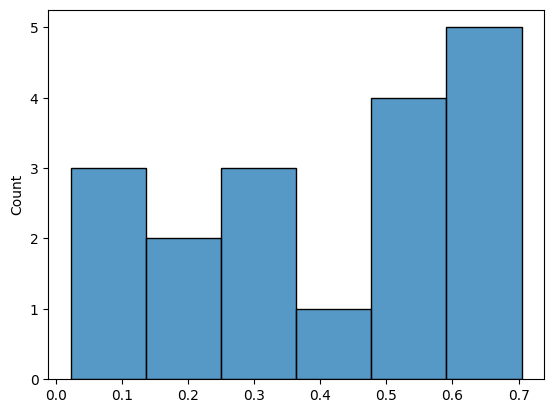

In [39]:
import seaborn as sns

sns.histplot(proportionOfExistence)